## Preping Data

In [1]:
import numpy as np
import glob
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# -------------------- SETTINGS --------------------
DATA_PATH = "gesture_data"   # Folder where your CSV files are
NUM_CLASSES = 6              # 0-5
# ---------------------------------------------------

X = []
y = []

# Load all CSV files
for class_id in range(NUM_CLASSES):
    class_path = os.path.join(DATA_PATH, str(class_id), "*.csv")
    files = glob.glob(class_path)
    for f in files:
        data = np.loadtxt(f, delimiter=",")
        X.append(data)
        y.append(class_id)

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape, y.shape)

# Normalize input coordinates (optional but recommended)
# Since MediaPipe landmarks are in range [0, 1], this may not be necessary
# X = X / np.max(X)

# Convert labels to one-hot encoding
y = to_categorical(y, NUM_CLASSES)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

2025-12-03 09:18:55.169278: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Dataset shape: (2998, 63) (2998,)
Training set: (2398, 63) (2398, 6)
Test set: (600, 63) (600, 6)


## Training

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# -------------------- MODEL --------------------
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='softmax')  # 6 classes: 0-5
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------- CALLBACKS --------------------
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('best_gesture_model.h5', monitor='val_loss', save_best_only=True)
]

# -------------------- TRAINING --------------------
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/100
62/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2083 - loss: 1.7781

75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2652 - loss: 1.7288 - val_accuracy: 0.5050 - val_loss: 1.5709
Epoch 2/100
61/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3746 - loss: 1.5812

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4003 - loss: 1.5105 - val_accuracy: 0.5833 - val_loss: 1.2698
Epoch 3/100
57/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4499 - loss: 1.3443

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5071 - loss: 1.2676 - val_accuracy: 0.6867 - val_loss: 1.0326
Epoch 4/100
58/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5602 - loss: 1.1305

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5784 - loss: 1.0948 - val_accuracy: 0.7467 - val_loss: 0.8686
Epoch 5/100
65/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6293 - loss: 0.9973

...

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9600 - loss: 0.1217 - val_accuracy: 0.9850 - val_loss: 0.0697
Epoch 75/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9646 - loss: 0.1028 - val_accuracy: 0.9883 - val_loss: 0.0745
Epoch 76/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9679 - loss: 0.1084 - val_accuracy: 0.9833 - val_loss: 0.0845
Epoch 77/100
64/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9671 - loss: 0.1040

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9683 - loss: 0.1075 - val_accuracy: 0.9850 - val_loss: 0.0683
Epoch 78/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9616 - loss: 0.1100 - val_accuracy: 0.9867 - val_loss: 0.0752
Epoch 79/100
66/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9698 - loss: 0.0995

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9646 - loss: 0.1038 - val_accuracy: 0.9883 - val_loss: 0.0671
Epoch 80/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9625 - loss: 0.1098 - val_accuracy: 0.9800 - val_loss: 0.0761
Epoch 81/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9621 - loss: 0.1190 - val_accuracy: 0.9867 - val_loss: 0.0681
Epoch 82/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9721 - loss: 0.0991 - val_accuracy: 0.9833 - val_loss: 0.0719
Epoch 83/100
65/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9712 - loss: 0.0823

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9666 - loss: 0.1026 - val_accuracy: 0.9883 - val_loss: 0.0649
Epoch 84/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9633 - loss: 0.1099 - val_accuracy: 0.9850 - val_loss: 0.0901
Epoch 85/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9612 - loss: 0.1204 - val_accuracy: 0.9767 - val_loss: 0.0820
Epoch 86/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9662 - loss: 0.1134 - val_accuracy: 0.9867 - val_loss: 0.0708
Epoch 87/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9716 - loss: 0.0889 - val_accuracy: 0.9900 - val_loss: 0.0664
Epoch 88/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9704 - loss: 0.0882 - val_accuracy: 0.9850 - val_loss: 0.0744
Epoch 89/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9675 - loss: 0.0947 - val_accuracy: 0.9917 - val_loss: 0.0726
Epoch 90/100
65/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9711 - loss: 0.0832

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9691 - loss: 0.0843 - val_accuracy: 0.9883 - val_loss: 0.0606
Epoch 91/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9700 - loss: 0.0948 - val_accuracy: 0.9867 - val_loss: 0.0691
Epoch 92/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9704 - loss: 0.1036 - val_accuracy: 0.9867 - val_loss: 0.0636
Epoch 93/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9750 - loss: 0.0816 - val_accuracy: 0.9883 - val_loss: 0.0791
Epoch 94/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9646 - loss: 0.1112 - val_accuracy: 0.9900 - val_loss: 0.0606
Epoch 95/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9671 - loss: 0.1000 - val_accuracy: 0.9867 - val_loss: 0.0776
Epoch 96/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9721 - loss: 0.0889 - val_accuracy: 0.9867 - val_loss: 0.0608
Epoch 97/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9746 - loss: 0.0803 - val_accuracy: 0.9867 - val_lo

## Evaluation

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

## Accuracy

In [5]:
loss, acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {acc*100:.2f}%")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9883 - loss: 0.0606 

Test Accuracy: 98.83%


## Confusion Matix

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       0.99      1.00      1.00       100
           2       1.00      0.99      0.99       100
           3       1.00      0.98      0.99       100
           4       0.98      0.98      0.98       100
           5       0.96      0.98      0.97       100

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



<Figure size 800x600 with 0 Axes>

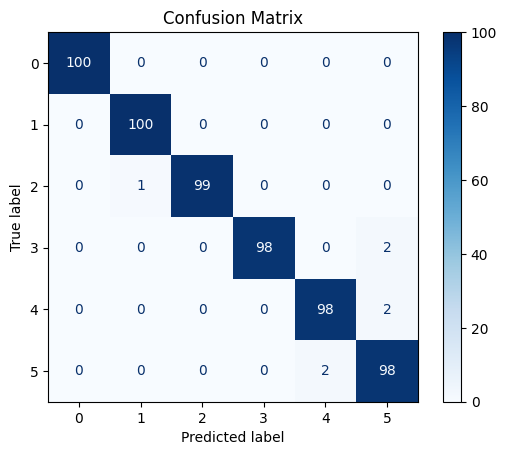

In [6]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes))

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4,5])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

## Performance Plots

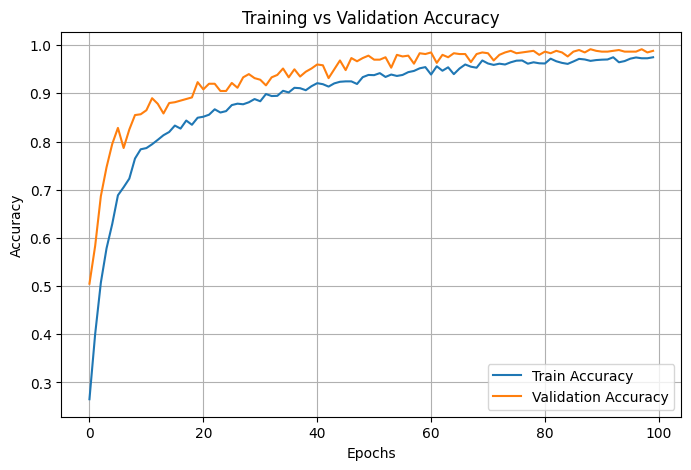

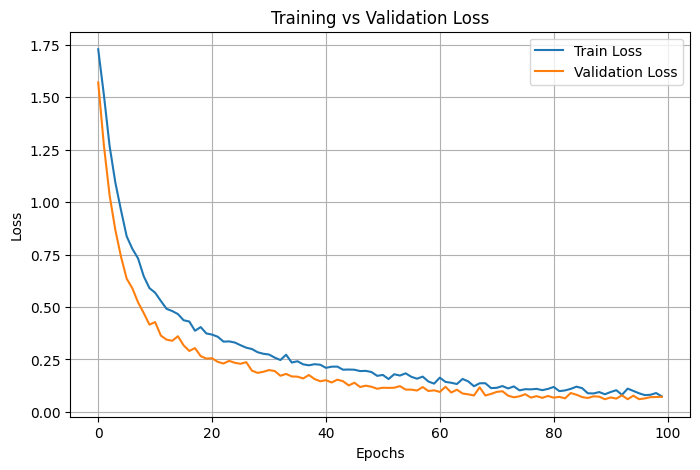

In [9]:
# Accuracy Plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss Plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()